In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest

Load Excel Files

In [3]:
members_df = pd.read_excel("/kaggle/input/main-transactions/main.xlsx",
                           engine = 'openpyxl', 
                           nrows = 50000)
txn_df = pd.read_excel("/kaggle/input/main-transactions/transactions.xlsx",
                           engine = 'openpyxl', 
                           nrows = 200000)

print(members_df.shape, txn_df.shape)


(50000, 18) (200000, 24)


Merge the datasets

In [4]:
df = txn_df.merge(members_df, on="MEMBER_ID", how="left")

print("Merged dataset:", df.shape)

Merged dataset: (200000, 41)


Feature Engineering

In [5]:
txn_counts = df.groupby("MEMBER_ID").size()

df["txn_frequency"] = df["MEMBER_ID"].map(txn_counts)

Remove Unnecessary Columns

In [6]:
drop_cols = [
    "FST_NAME",
    "MID_NAME",
    "LAST_NAME",
    "EMAIL_ADDRESS",
    "MOBILE",
    "VEHICLE_NO"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

Convert Date Columns

In [7]:
date_cols = ["TXN_DT", "BIRTH_DT", "ON_BOARD_DT"]

for col in date_cols:
    
    if col in df.columns:
        
        df[col] = pd.to_datetime(df[col], errors="coerce")
        
        df[col] = df[col].astype("int64") // 10**9

Encode Categorical Columns

In [8]:
label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col].astype(str))
    
    label_encoders[col] = le

Handle Missing Values

In [9]:
df = df.fillna(0)

Prepare Model Features

In [10]:
drop_cols = ["MEMBER_ID", "TXN_NUM"]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Feature matrix:", X.shape)

Feature matrix: (200000, 34)


Scale Features

In [11]:
for col in X.columns:
    if X[col].dtype == "datetime64[ns]":
        X[col] = X[col].astype("int64") // 10**9

X = X.apply(pd.to_numeric, errors="coerce")

X = X.fillna(0)

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train Isolation Forest

In [13]:
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

df["anomaly_flag"] = iso_forest.fit_predict(X_scaled)

Conver Output to Binary

In [14]:
df["is_anomaly_if"] = (df["anomaly_flag"] == -1).astype(int)

Count Anomalies

In [15]:
print("Total anomalies detected:")
print(df["is_anomaly_if"].sum())

Total anomalies detected:
10000


Isolation Forest Score

In [16]:
df["anomaly_score_if"] = iso_forest.decision_function(X_scaled)

View Top Suspicious Transactions

Clean Output Analysis

In [18]:
important_cols = [
    "MEMBER_ID",
    "TXN_NUM",
    "AMOUNT",
    "TRANSACTION_TYPE",
    "CHANNEL",
    "RO_CODE",
    "STATE_OFFICE",
    "txn_frequency",
    "anomaly_score_if",
    "is_anomaly_if"
]

anomaly_report = df[important_cols]

Save Results

In [19]:
anomaly_report.to_csv("isolation_forest_results.csv", index=False)

In [21]:
total_rows = len(df)
total_anomalies = df["is_anomaly_if"].sum()

print("Total rows:", total_rows)
print("Anomalies detected:", total_anomalies)
print("Anomaly percentage:", (total_anomalies/total_rows)*100)

Total rows: 200000
Anomalies detected: 10000
Anomaly percentage: 5.0


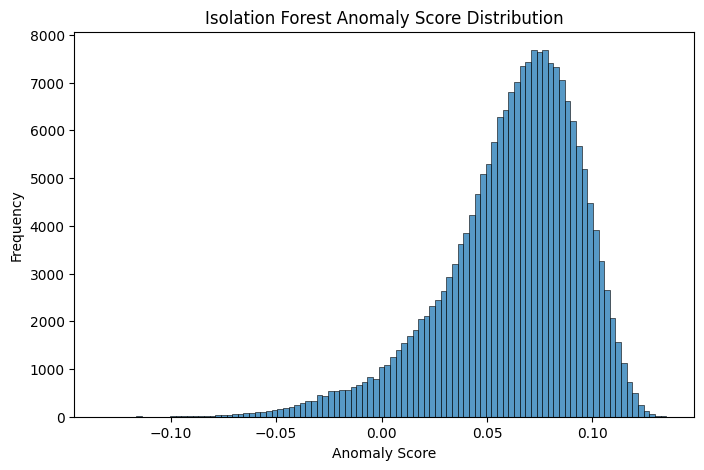

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df["anomaly_score_if"], bins=100)

plt.title("Isolation Forest Anomaly Score Distribution")

plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")

plt.show()

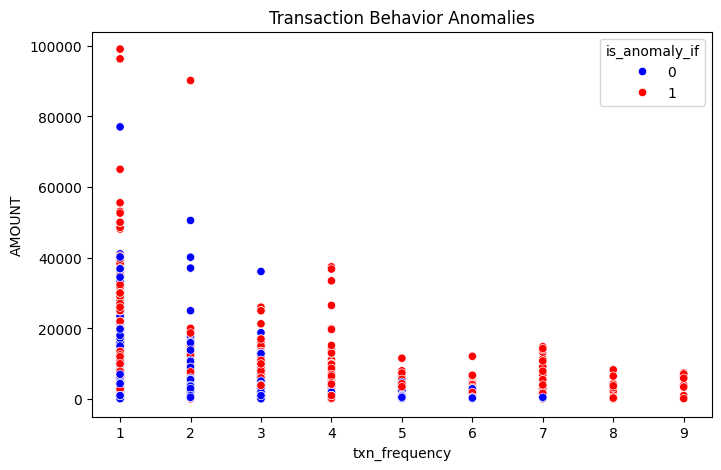

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="txn_frequency",
    y="AMOUNT",
    hue="is_anomaly_if",
    data=df,
    palette={0:"blue",1:"red"}
)

plt.title("Transaction Behavior Anomalies")

plt.show()

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:,0]
df["pca2"] = X_pca[:,1]

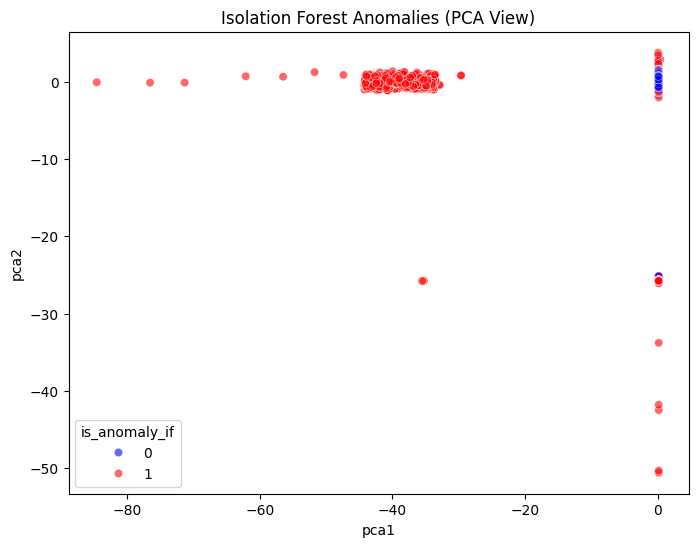

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="pca1",
    y="pca2",
    hue="is_anomaly_if",
    data=df,
    palette={0:"blue",1:"red"},
    alpha=0.6
)

plt.title("Isolation Forest Anomalies (PCA View)")

plt.show()

In [26]:
summary = pd.DataFrame({
    "Metric":[
        "Total transactions",
        "Isolation Forest anomalies",
        "Anomaly percentage"
    ],
    "Value":[
        len(df),
        df["is_anomaly_if"].sum(),
        (df["is_anomaly_if"].mean()*100)
    ]
})

summary

,Metric,Value
0,Total transactions,200000.0
1,Isolation Forest anomalies,10000.0
2,Anomaly percentage,5.0


In [27]:
iso_results = df[[
    "MEMBER_ID",
    "TXN_NUM",
    "anomaly_score_if",
    "is_anomaly_if"
]]

iso_results.to_csv("if_results.csv", index=False)